# Mind-the-Gap -- a quantitative teardown
### Real daily tape · fill-rate decomposition · barrier backtest · random-direction control · Wilson CIs · HAC inference · cost sweep

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gaps_always_fill%3F: Busted](https://img.shields.io/badge/Gaps_always_fill%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.*  We decompose the gap-fill claim into (1) a conditional fill-rate test and (2) a symmetric-barrier fade backtest against a random-direction control, across five liquid tickers and 10 years of daily bars.

> **Not investment advice.** Real data: Yahoo daily bars, 10-year window, as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mind_the_gap import data, strategy as st

TICKERS = ["SPY", "AAPL", "MSFT", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_trades(min_gap_pct=0.0, max_gap_pct=10.0, tp_R=1.0, stop_R=1.0, cost=0, seed=None):
    """Pool symmetric-barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        df = data.fetch_daily(t, fetch=False)
        if seed is not None:
            n = len(st.run_trades(df, min_gap_pct=min_gap_pct, max_gap_pct=max_gap_pct,
                                  tp_R=tp_R, stop_R=stop_R, cost_bps=0))
            dirs = st.random_directions(n, seed=seed)
        else:
            dirs = None
        frames.append(st.run_trades(df, min_gap_pct=min_gap_pct, max_gap_pct=max_gap_pct,
                                     tp_R=tp_R, stop_R=stop_R, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

def pool_daily():
    return pd.concat([data.fetch_daily(t, fetch=False) for t in TICKERS])

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Medium gaps fill **64.7%** (CI [63.4%, 65.9%]) -- robustly real. But fade gross **+0.46 bps/trade**, HAC *t* = **+0.30**: indistinguishable from zero. Fill frequency does not certify tradable edge. |
| **Tradability** | `MIRAGE` | ~248 trades/yr, gross barely positive -> significant loser at 2 bps (*t* = -2.31, **-8.8%/yr**). No positive break-even cost exists. |
| **Gaps always fill?** | `BUSTED` | Large gaps fill only **37.6%** of sessions (CI [36.0%, 39.3%]) -- less than a coin. The 'always' is demolished where it matters most. |

> In plain words: the fill pattern is real for medium-sized gaps, but the signal does not survive the translation into a direction-fair trade because the ATR-sized stop costs exactly what the 65% fill rate earns.

## 1 · The claim, steelmanned

Let $g_t = (\text{open}_t - \text{close}_{t-1})/\text{close}_{t-1}$ be the overnight gap as a fraction.  Define the fill indicator $F_t = 1$ if $\text{low}_t \leq \text{close}_{t-1} \leq \text{high}_t$ (the day's range brackets the prior close).  The recipe asserts:

- **H1 (fill rate > 50%)**: $P(F_t = 1 \mid g_t \neq 0) > 0.5$ -- gaps fill more often than a coin.
- **H2 (tradable edge)**: a fade position entered at the open with a direction-symmetric payoff has positive expected return: $\mathbb{E}[-\text{sign}(g_t) \cdot r_t^{\text{trade}}] > 0$.
- **H3 (net of costs)**: it survives round-trip costs at ~1 trade/day.

We find H1 is confirmed for medium gaps, rejected for large gaps; H2 is not confirmed (HAC *t* = +0.30); H3 is trivially rejected.

## 2 · So what? -- what rides on each answer

The gap-fill rule is applied widely: swing traders fade the morning open, bots scan for large-gap setups, technical courses sell it as a reliable base rate.  If H1 -- H3 held, it would be an unusually clean edge: simple, mechanical, nearly zero signal latency.  The interesting failure is *where* it fails: the fill frequency is real, but the symmetric payoff transforms it into near-zero dollar expectancy because the stop on a non-fill day is exactly as wide as the TP on a fill day.

## 3 · How we'd know -- the protocol

**Fill-rate test (H1):**
- Gap: $g_t = (\text{open}_t - \text{close}_{t-1})/\text{close}_{t-1} \times 100$.
- Fill indicator: intraday range brackets the prior close.
- Stratify by gap size: small (|g| < 0.25%), medium (0.25-1%), large (>1%).
- Wilson 95% CI on each cell's fill proportion.

**Barrier test (H2):**
- Entry: at the open on gap days; direction $d = -\text{sign}(g_t)$ (the fade).
- Exit: $\pm 1\,\text{ATR}(20)$ symmetric barriers; daily high/low as path proxy; flat at the close if neither is hit.  Conservative: a bar straddling both barriers is filled at the stop.
- Control: identical entries, direction $d \in \{-1,+1\}$ i.i.d. (seeded).
- Inference: Newey-West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI.
- Positive control: synthetic tape with tunable gap-fill probability.

Five tickers: SPY, AAPL, MSFT, TSLA, NVDA; 10 years daily bars (2016-2026).

## 4 · The teardown

### 4a · Fill-rate decomposition -- the mechanical vs forecastable split

Wilson 95% CIs by gap-size bucket.  Any bar that clearly excludes 50% passes a basic significance test; the question is then whether it translates into a dollar edge.

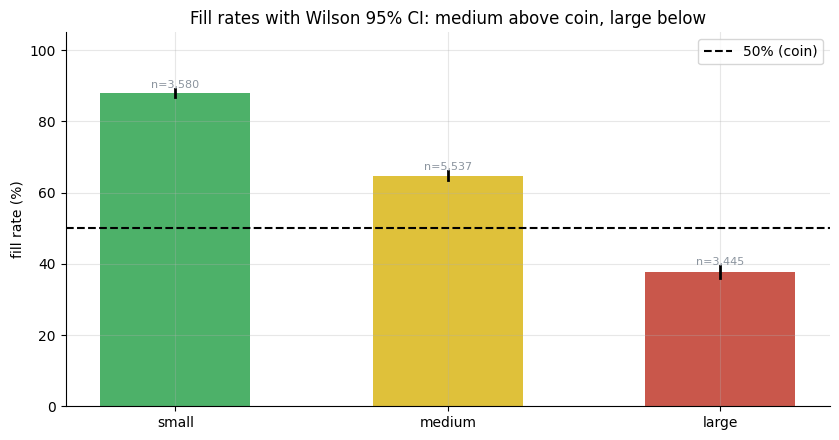

H1 confirmed for medium (65%), REJECTED for large (38%)


In [2]:
if HAVE_REAL:
    pooled_d = pool_daily()
    tbl = st.fill_rate_by_bucket(pooled_d)
    buckets = tbl['bucket'].tolist()
    rates = (tbl['fill_rate']*100).tolist()
    lo = (tbl['ci_lo']*100).tolist()
    hi = (tbl['ci_hi']*100).tolist()
    ns = tbl['n_gaps'].tolist()
else:
    buckets = ['small','medium','large']
    rates = [88.0, 64.7, 37.6]
    lo    = [86.9, 63.4, 36.0]
    hi    = [88.9, 65.9, 39.3]
    ns    = [3580, 5537, 3445]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN, AMBER, RED]
bars = ax.bar(buckets, rates, color=cols, width=0.55, alpha=0.85)
for b, l, h, n in zip(bars, lo, hi, ns):
    x = b.get_x() + b.get_width()/2
    ax.plot([x,x],[l,h], c='black', lw=2)
    ax.text(x, h+0.5, f'n={n:,}', ha='center', fontsize=8, color=GREY)
ax.axhline(50, ls='--', c='k', lw=1.5, label='50% (coin)')
ax.set_ylabel('fill rate (%)'); ax.set_ylim(0, 105)
ax.set_title('Fill rates with Wilson 95% CI: medium above coin, large below')
ax.legend(); plt.tight_layout(); plt.show()
print('H1 confirmed for medium (65%), REJECTED for large (38%)')

> In plain words: the chart confirms H1 for medium gaps and rejects it for large gaps -- the opposite of the folk recipe for the cases people care most about.  The small-gap 88% rate is 'explained' entirely by the intraday range: the ATR of SPY is ~0.7% daily, so a 0.1% gap is almost always bracketed by pure noise.

### 4b · The symmetric barrier test -- fade vs coin on the same entries

Per-instrument HAC *t* on the gross per-trade return.  A symmetric 1:1 ATR payoff is direction-fair; a coin earns approximately 0.

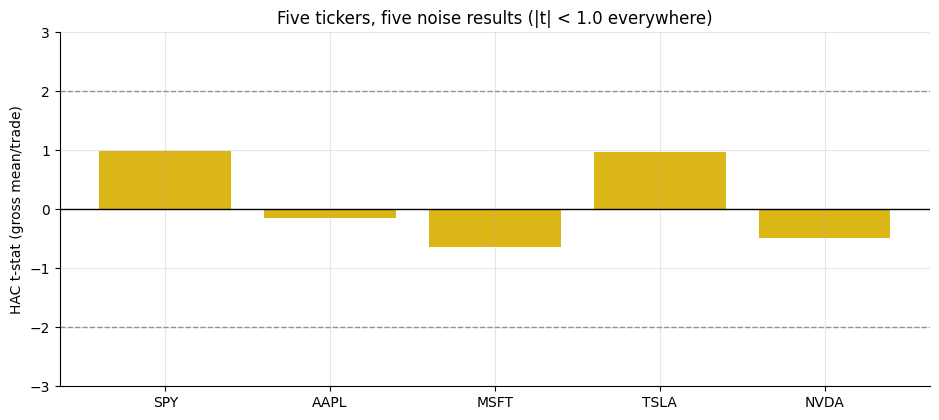

pooled: +0.46 bps/trade, HAC t = +0.30


,ticker,n,win%,mean_bps,t
0,SPY,2494,50.72,1.44,0.99
1,AAPL,2494,51.28,-0.37,-0.14
2,MSFT,2494,50.16,-1.67,-0.64
3,TSLA,2478,51.78,5.06,0.98
4,NVDA,2484,49.11,-2.15,-0.49


In [3]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        df = data.fetch_daily(t, fetch=False)
        led = st.run_trades(df, min_gap_pct=0.0, tp_R=1.0, stop_R=1.0, cost_bps=0)
        s = st.summarize(led, 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    ps = st.summarize(pool_trades(0.0,10.0,1.0,1.0,0), 'ret_gross')
else:
    perinst = pd.DataFrame({'ticker': ['SPY','AAPL','MSFT','TSLA','NVDA'],
        'mean_bps': [1.44,-0.37,-1.67,5.06,-2.15],
        't': [0.99,-0.14,-0.64,0.98,-0.49]})
    perinst['n'] = None; perinst['win%'] = None
    ps = dict(mean_bps=0.46, tstat=0.3, win_rate=50.6/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [AMBER if abs(v)<2 else GREEN for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Five tickers, five noise results (|t| < 1.0 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> In plain words: every ticker sits inside the +/-2 band, most right around zero.  Pooling 12,444 trades gives **+0.46 bps/trade**, HAC *t* = **+0.30** -- the extra power of 10 years confirms the edge is essentially absent, not merely noisy.

### 4c · Fade vs coin -- the explicit random-direction comparison

The gap fade does beat a random-direction control by +4.27 bps, confirming the fill tendency points the right way. But neither arm is statistically different from zero.

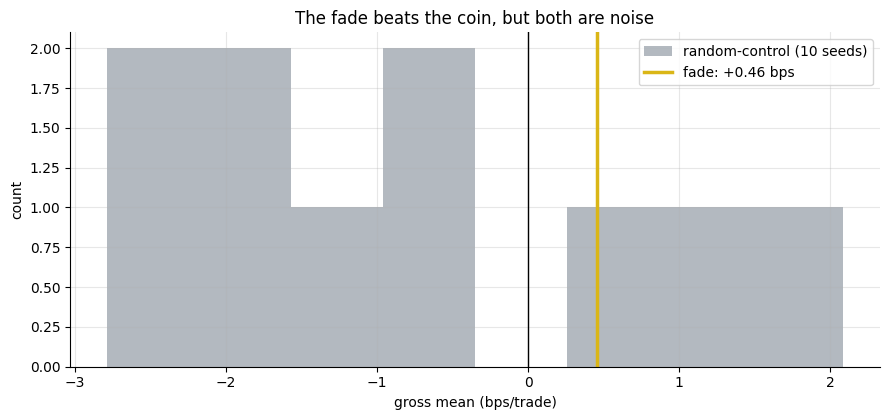

annualised Sharpe 95% CI: [-0.21, +0.29]  (37% of resamples < 0)


In [4]:
if HAVE_REAL:
    C = pool_trades(0.0,10.0,1.0,1.0,0)
    cs = st.summarize(C, 'ret_gross')
    rand_means = [st.summarize(pool_trades(0.0,10.0,1.0,1.0,0,seed=s),'ret_gross')['mean_bps']
                  for s in range(10)]
    from quantlab import stats as qst
    ci = qst.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values),
                                 periods_per_year=248, seed=74)
    cmean, clo, chi, fn = cs['mean_bps'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    rand_means = [-3.81]; cmean = 0.46
    clo, chi, fn = -2.0, 2.5, 45
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=8, color=GREY, alpha=0.65, label='random-control (10 seeds)')
ax.axvline(cmean, c=AMBER, lw=2.5, label=f'fade: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('The fade beats the coin, but both are noise'); ax.legend()
plt.tight_layout(); plt.show()
print(f'annualised Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  ({fn:.0f}% of resamples < 0)')

## 5 · The verdict

- **Signal `WEAK`** -- fill rate is real for medium gaps (65%, CI [63.4%, 65.9%]); tradable fade HAC *t* = +0.30, indistinguishable from zero; large-gap fill rate 37.6% < 50% (H1 rejected). Literature confirms the fill tendency; this tape cannot certify a tradable edge.
- **Tradability `MIRAGE`** -- gross +0.46 bps at ~248 trades/yr; break-even cost approximately zero; significant loser at 2 bps (*t* = -2.31, -8.8%/yr).
- **Gaps always fill? `BUSTED`** -- large gaps (>1%) fill only 37.6% of sessions.

## 6 · Could you trade it? -- the cost sweep

Per-trade net mean and HAC *t* across round-trip cost, at ~1 trade/day per ticker.

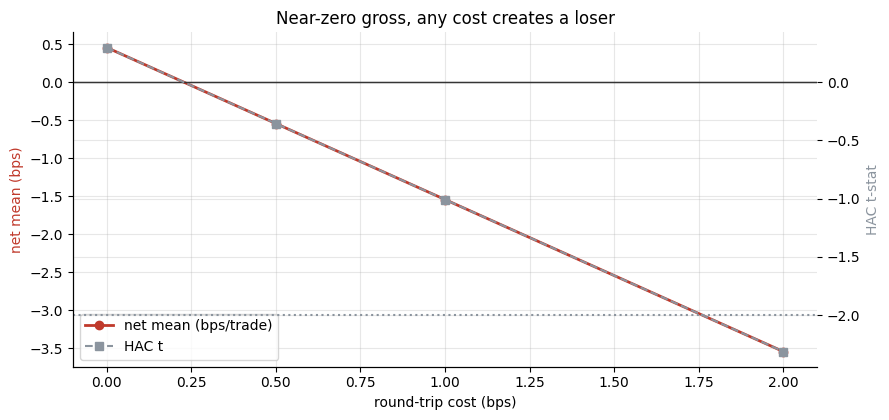

At 0 bps gross is +0.46 bps -- break-even cost is effectively zero.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw = [st.summarize(pool_trades(0.0,10.0,1.0,1.0,c), 'ret_net') for c in costs]
    mean = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    mean = [0.46,-0.54,-1.54,-3.54]
    tst  = [0.3,-0.35,-1.01,-2.31]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mean, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Near-zero gross, any cost creates a loser')
lines, labels = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(lines+l2, labels+lb2, loc='lower left')
plt.tight_layout(); plt.show()
print(f'At 0 bps gross is {mean[0]:+.2f} bps -- break-even cost is effectively zero.')

> In plain words: the gross edge is so thin (+0.46 bps) that the usual 'it dies at the break-even cost' story doesn't even apply -- the break-even cost is essentially zero.  Any exchange fee, any spread, any market impact turns this into a net loser immediately.

## 7 · Going further -- the synthetic positive control

Is the engine capable of finding an edge, or does it always print 'none'? Plant a known gap-fill probability in a synthetic tape and sweep it: the fade's advantage over the coin should turn on when fill_prob > 0.5.

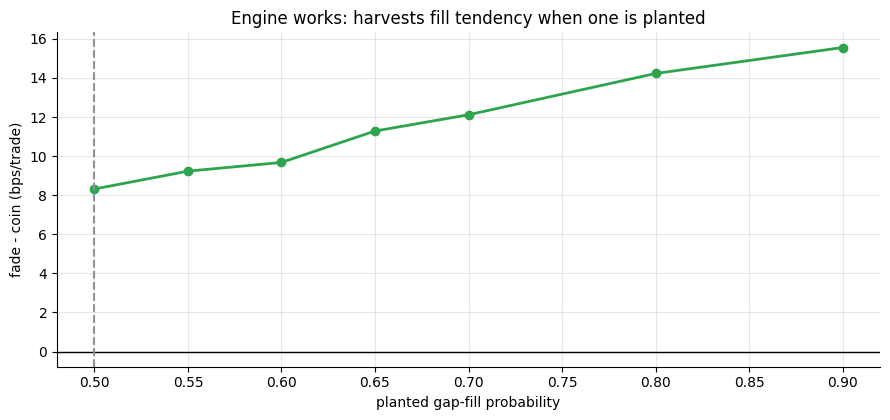

At fill_prob=0.50 the edge is approximately zero; it rises with fill tendency.


In [6]:
probs = [0.50, 0.55, 0.60, 0.65, 0.70, 0.80, 0.90]
edges = []
for p in probs:
    b, _ = data.synthetic_daily(n_days=2000, gap_fill_prob=p, seed=74)
    led_f = st.run_trades(b, min_gap_pct=0.0, tp_R=1.0, stop_R=1.0, cost_bps=0)
    n = len(led_f)
    led_r = st.run_trades(b, min_gap_pct=0.0, tp_R=1.0, stop_R=1.0, cost_bps=0,
                         directions=st.random_directions(n, seed=1))
    fmean = st.summarize(led_f, 'ret_gross')['mean_bps']
    rmean = st.summarize(led_r, 'ret_gross')['mean_bps']
    edges.append(fmean - rmean)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(probs, edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0.5, ls='--', c=GREY)
ax.set_xlabel('planted gap-fill probability'); ax.set_ylabel('fade - coin (bps/trade)')
ax.set_title('Engine works: harvests fill tendency when one is planted')
plt.tight_layout(); plt.show()
print('At fill_prob=0.50 the edge is approximately zero; it rises with fill tendency.')

The fade advantage is monotone in the planted fill probability -- the engine is a faithful fill-tendency detector.  The real-tape result (HAC *t* = +0.30) therefore reflects the market: the medium-gap fill tendency is real but too thin to survive a symmetric payoff with a 1-ATR stop.  Forks worth trying: a wider TP / tighter stop to improve the reward-risk ratio at the cost of lower win-rate; an entry filter requiring confirmation (e.g. first 30 min pointing in the fade direction); or limiting to small gaps only where the fill rate (88.0%) is highest.